In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import KFold
from sklearn.base import BaseEstimator

## Provided Functions

In [2]:
def read_points_data(filter_1: str, filter_2: str, split_data: bool = False) -> pd.DataFrame | tuple[pd.Series, pd.Series]:
    """
    This helper function reads in the `points.csv` file and filters the data base on two specifies rows. 

    Args:
        filter_1 (str): The first row value to filter by.
        filter_2 (str): The second row value to filter by.
        split_data (bool): Indicates whether to split the data into two separate datasets or not.

    Returns:
        pd.DataFrame: A `pandas` `DataFrame` containing the filtered data OR
        tuple[pd.Series, pd.Series]: Two separated `pandas` `Series` containing the filtered data.
    """
    data = pd.read_csv("points.csv")
    if split_data:
        data1 = data[data["lecturer"] == filter_1]
        data2 = data[data["lecturer"] == filter_2]
        return data1.points, data2.points

    return data[data["lecturer"].isin([filter_1, filter_2])]

def read_games_data(relevant_columns: list[str], split_data: bool = False) -> pd.DataFrame | tuple[pd.Series, ...]:
    """
    This helper function reads in the `games.csv` file and filters the data based on the given `relevant_columns`.

    Args:
        relevant_columns (list[str]): The columns that should be kept.
        split_data (bool): Indicates whether to split the data into separate datasets or not.

    Returns:
        pd.DataFrame: A `pandas` `DataFrame` containing the relevant columns data OR
        tuple[pd.Series, ...]: Separated `pandas` `Series` containing the relevant columns.
    """
    data = pd.read_csv("games.csv")
    if split_data:
        return tuple(data[col] for col in relevant_columns)

    return data[relevant_columns]

## Permutation Test

In [3]:
def permutation_test(data_1: pd.Series, data_2: pd.Series, num_permutations: int, random_state: int = 0) -> float:
    """
        This function takes two `pandas` `Series` and performs a permutation test 
        to determine if they come from different distributions.

    Args:
        filter_1 (str): The first row value to filter by.
        data_1 (pd.Series): First data series.
        data_2 (pd.Series): Second data series.
        num_permutations (int): Number of permutations.
        random_state: The random seed to use for reproducibility.

    Returns:
        p-value (float): The proportion of permutations where the test statistic exceeds the observed statistic.
    """
    np.random.seed(random_state)

    datas = [data_1, data_2]
    pool = pd.concat(datas, ignore_index=True).values
    x = len(data_1)

    diff = abs(data_1.mean() - data_2.mean())

    diffs_star = []
    count = 0
    for i in range(num_permutations):
        np.random.shuffle(pool)
        diff_star = abs(pool[:(x)].mean() - pool[(x):].mean())
        diffs_star.append(diff_star)
        if diff_star >= diff:
            count += 1

    p_value = (count + 1) / (num_permutations + 1)
    return p_value

# With splitting the data:
points_1, points_2 = read_points_data("A", "B", True)
# And without splitting the data:
points = read_points_data("C", "D", False)

p_value = permutation_test(data_1=points_1, data_2=points_2, num_permutations=75000, random_state=12538316)
print(f"p-value: {p_value}")

p-value: 0.008266556445914055


## Linear Regression with Least Squares

slope: 0.158, intercept: 5.23, RSS: 163116.264


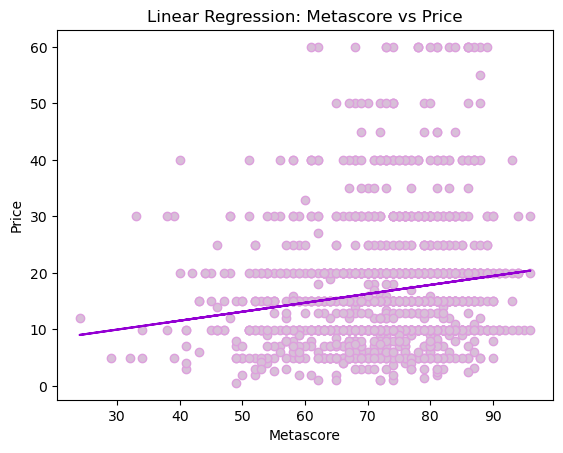

In [4]:
def linear_regression(x: pd.Series, y: pd.Series) -> tuple[float, float, float]:
    """
    Fits a linear regression model using the least squares method.

    Args:
        x (pd.Series): Independent variable.
        y (pd.Series): Dependent variable (price).

    Returns:
        slope (float): Estimated slope of the regression line.
        intercept (float): Estimated intercept of the regression line.
        rss (float): Residual sums of squares.
    """

    x = x.values.reshape(-1, 1) #also needed so its 2d

    model = LinearRegression()
    model.fit(x, y)
    y_pred = model.predict(x)

    slope = model.coef_[0] #The [0] is needed so it becomes a float instead of an array
    intercept = model.intercept_
    rss = np.sum((y - y_pred) ** 2)

    return slope, intercept, rss


def plot_regression_line(x: pd.Series, y: pd.Series, slope: float, intercept: float) -> None:
    """
    Plots the regression line on a scatterplot of the data.

    Args:
        x (pd.Series): Independent variable.
        y (pd.Series): Dependent variable (price).
        slope (float): Slope of the regression line.
        intercept (float): Intercept of the regression line.

    Returns:
        None.
    """

    plt.scatter(x, y, color="thistle", edgecolors="plum")

    reg_line = (slope) * x + intercept
    plt.plot(x,reg_line, color="darkviolet", label="Regression line")

    plt.xlabel("Metascore")
    plt.ylabel("Price")
    plt.title("Linear Regression: Metascore vs Price")

    plt.show()
    
    pass

# Example usage of the `read_games_data` function with splitting the data:
x, y = read_games_data(["metascore","price"], True)
# And without splitting the data:
data = read_games_data(["metascore","price"], False)

slope, intercept, rss = linear_regression(read_games_data("metascore"), read_games_data("price"))
print(f"slope: {round(slope, 3)}, intercept: {round(intercept, 3)}, RSS: {round(rss, 3)}")

plot_regression_line(read_games_data("metascore"), read_games_data("price"), slope, intercept)

## Cross-Validation and Model Selection

Linear - Mean RSS: 32737.676147773418
Ridge - Mean RSS: 32737.675981900153


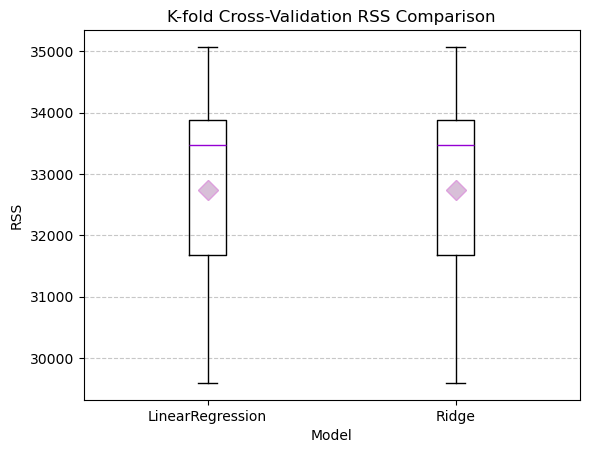

In [22]:
def k_fold_cross_validation(x: pd.Series, y: pd.Series, model: BaseEstimator, k: int = 5, random_state: int = 0) -> list:
    """
    Performs k-fold cross-validation to evaluate the linear regression model.

    Args:
        x (pd.Series): Independent variable. 
        y (pd.Series): Dependent variable (price).
        model (sklearn.base.BaseEstimator): The initialized model object of class LinearRegression or Ridge.
        k (int): Number of folds.
        random_state: The random seed to use for reproducibility.

    Returns:
        k_rss (list): A list of k Residual Sum of Squares for each fold.
    """

    random_state = 12538316
    X = x.values.reshape(-1, 1)

    kf = KFold(n_splits=k, shuffle=True, random_state=random_state)
    k_rss = []
    
    for train, test in kf.split(X):
        X_train, X_test, y_train, y_test = X[train], X[test], y[train], y[test]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        rss = np.sum((y_test - y_pred) ** 2)
        k_rss.append(rss)
        
    return k_rss


def plot_boxplot_cross_validation(metrics: dict[str, list[float]]) -> None:
    """
    Plots the cross-validation metrics as a boxplot for each model in the metrics dictionary.

    Args:
        metrics (dict): A dictionary containing the cross-validation metrics for each model: key is model name and value is a list of metric values (e.g., RSS).

    Returns:
        None.
    """

    key = list(metrics.keys())
    value = list(metrics.values())
    
    mean_props = {
    "marker": "D",       # Diamond shape
    "markerfacecolor": "thistle",
    "markeredgecolor": "plum",
    "markersize": 10
    }

    median_props = {
    "color": "darkviolet",
    "linewidth": 1
    }
    
    box = plt.boxplot(value, tick_labels=key, showmeans=True, meanprops=mean_props, medianprops=median_props)

    plt.xlabel("Model")
    plt.ylabel("RSS")
    plt.title("K-fold Cross-Validation RSS Comparison")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    pass


x, y = read_games_data(["metascore","price"], True)

linear_model = LinearRegression()
ridge_model = Ridge()

k_rss_linear = k_fold_cross_validation(x, y, linear_model)
k_rss_ridge = k_fold_cross_validation(x, y, ridge_model)

print(f"Linear - Mean RSS: {np.mean(k_rss_linear)}")
print(f"Ridge - Mean RSS: {np.mean(k_rss_ridge)}")

metrics = {'LinearRegression': k_rss_linear, 'Ridge': k_rss_ridge}

plot_boxplot_cross_validation(metrics)